### Dynamic Feature Extraction - Multiclass (Using MobileNetV3)

**AIM**: Build and train an image classifier to detect images from different animal species using a pre-trained MobileNetV3 model.

### Objectives
- Data visualisation
- Data preprocessing and image augmentation
- Use a pre-trained CNN Model for transfer learning (dynamic feature extraction)
- Base model runs every epoch and supports data augmentation and fine-tuning
- Compile and train the model
- Add early stopping callback (optional)
- Save and load model
- Model evaluation
- Make prediction on new data

### Prerequisite
- Google colab or Jupyter notebook
- animal-image-classification-dataset
- TensorFlow2

### Check if TensorFlow, NumPy, Pandas and Matplotlib are installed

In [ ]:
!pip show tensorflow

In [ ]:
# !pip show numpy

In [ ]:
# !pip show pandas

In [ ]:
!pip show matplotlib

In [ ]:
import os
import sys
import random
import pathlib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
# Set seed for reproducibility

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
# Check for GPU
!nvidia-smi

In [ ]:
# Check if TensorFlow can detect any GPU
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print(f"GPUs available: {len(gpus)}")

    for gpu in gpus:
        print(f"- {gpu}")
else:
    print("No GPUs found.")

In [ ]:
gpus = tf.config.list_physical_devices("GPU")
gpus

In [ ]:
# Get the total number of GPUs and names
if gpus:
    print(f"Total number of GPUs: {len(gpus)}")
    
    for gpu in gpus:
        print(f"GPU Name: {gpu}")
else:
    print("No GPU available")

In [ ]:
# Check TensorFlow version
print(f"TensorFlow Version: {tf.__version__}")

In [ ]:
# CReate a director called "models" to store model files during training

if not os.path.isdir("models"):
    os.mkdir("models")

In [ ]:
## Set the base path
base_dir = "../../datasets/dog_vs_cats"
base_dir = pathlib.Path(base_dir)
base_dir

In [ ]:
# Train directory
train_dir = base_dir / "train"
train_dir

In [ ]:
# Validation directory
test_dir = base_dir / "test"
test_dir

In [ ]:
# Validation directory
validation_dir = base_dir / "validation"
validation_dir

In [ ]:
IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
BATCH_SIZE = 32
EPOCHS = 300

In [ ]:
# Load the training dataset
# Using `image_dataset_from_directory (recommended and stable)
# Instead of using the 'ImageDataGenerator()' class

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED,
)

In [ ]:
# Load the validation dataset

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED,
)

In [ ]:
# Load the validation dataset

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED,
)

In [ ]:
# Get the class names
class_names = train_dataset.class_names
number_classes = len(class_names)

print(f"Number of classes: {number_classes}")
print(f"Class names: {list(class_names)}")

### Sanity Check: Visualise dataset samples 
- Confirms correct labels
- Detects corrupt images
- Verifies colour channels, orientation, resolution

In [ ]:
# Verify (test)

train_dataset.take(1)

In [ ]:
# Capture exactly ONE batch and store it in memory
# This "freezes" the random augmentations for this specific set
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

In [ ]:
# Visualisation
# No matter how many times you run this cell, the images won't change.
plt.figure(figsize=(12, 12))
for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype("uint8"))
    plt.title(class_names[fixed_labels[i]])
    plt.axis("off")

### Performance Optimisation

Using `tf.data.AUTOTUNE` and the specific method below creates an asynchronous pipeline—basically, it allows the CPU to prepare the next batch while the GPU is still processing the current one.

In [ ]:
# AUTOTUNE allows TensorFlow to dynamically adjust the resource allocation 
# (like CPU threads) based on your hardware's current workload at runtime.
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (
    train_dataset
    # Keep the data in memory (RAM) after the first epoch.
    # This prevents the CPU from having to re-read and re-decode JPEGs 
    # from the slow hard drive during every subsequent training round.
    .cache()

    # Maintain a buffer of 1,000 samples and randomly pulls from it.
    # This ensures the model doesn't learn the order of the files, 
    # but rather the features of the images.
    .shuffle(1000)

    # Overlaps the data preprocessing and model execution.
    # While the GPU is training on the current batch, the CPU is already 
    # preparing the next batch in the background. This eliminates "GPU starvation."
    .prefetch(buffer_size=AUTOTUNE)
)

In [ ]:
validation_dataset = (
    validation_dataset
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

In [ ]:
test_dataset = (
    test_dataset
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

### Data Augmentation (Modern Keras Layers)

In [ ]:
# Data Augmentation

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

In [ ]:
# Instantiate Base Model

INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH) + (3,)

base_model = tf.keras.applications.MobileNetV3Large(
    weights="imagenet",
    input_shape=INPUT_SHAPE,
    include_top=False,
)

base_model.trainable = False

In [ ]:
base_model.summary()

In [ ]:
# Define the input tensor, apply data augmentation to improve generalisation
# and preprocess images to match ResNet's expected input format.

inputs = tf.keras.Input(shape=INPUT_SHAPE)
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v3.preprocess_input(x)

In [ ]:
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)

In [ ]:
# Add a classification head

x = tf.keras.layers.Dense(units=128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.3)(x)

In [ ]:
number_classes

In [ ]:
# Add the outputs
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

In [ ]:
model = tf.keras.Model(inputs, outputs)
model.summary()

### Build and Compile the Model

In [ ]:
# Compile the model

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-7),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

### Configure Callbacks

In [ ]:
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="models/mobilenetv3large.keras",
    monitor="val_accuracy",
    save_best_only=True,
    # verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_learning_rate = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=5,
    verbose=1
)


callbacks = [model_checkpoint, early_stopping, reduce_learning_rate]

### Train the model to learn patterns from the images

In [77]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.5312 - loss: 0.8185 - val_accuracy: 0.5474 - val_loss: 0.7351 - learning_rate: 1.0000e-07
Epoch 2/300
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.5399 - loss: 0.8036 - val_accuracy: 0.5552 - val_loss: 0.7252 - learning_rate: 1.0000e-07
Epoch 3/300
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.5487 - loss: 0.7968 - val_accuracy: 0.5638 - val_loss: 0.7155 - learning_rate: 1.0000e-07
Epoch 4/300
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.5563 - loss: 0.7862 - val_accuracy: 0.5746 - val_loss: 0.7059 - learning_rate: 1.0000e-07
Epoch 5/300
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.5498 - loss: 0.7839 - val_accuracy: 0.5844 - val_loss: 0.6964 - learning_rate: 1.0000e-07
Epoch 6/300
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.5588 - loss: 0.7777 - val_accuracy: 0.5960 - val_loss: 0.6869 - learning_rate: 1.0000e-07
Epoch 7/300
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - a

### Plot Training Curves (Learning Dynamics)

In [78]:
def plot_learning_curves(history):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(len(acc))


    plt.figure(figsize=(18, 7))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.legend()
    plt.title("Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.legend()
    plt.title("Loss")

    plt.show()


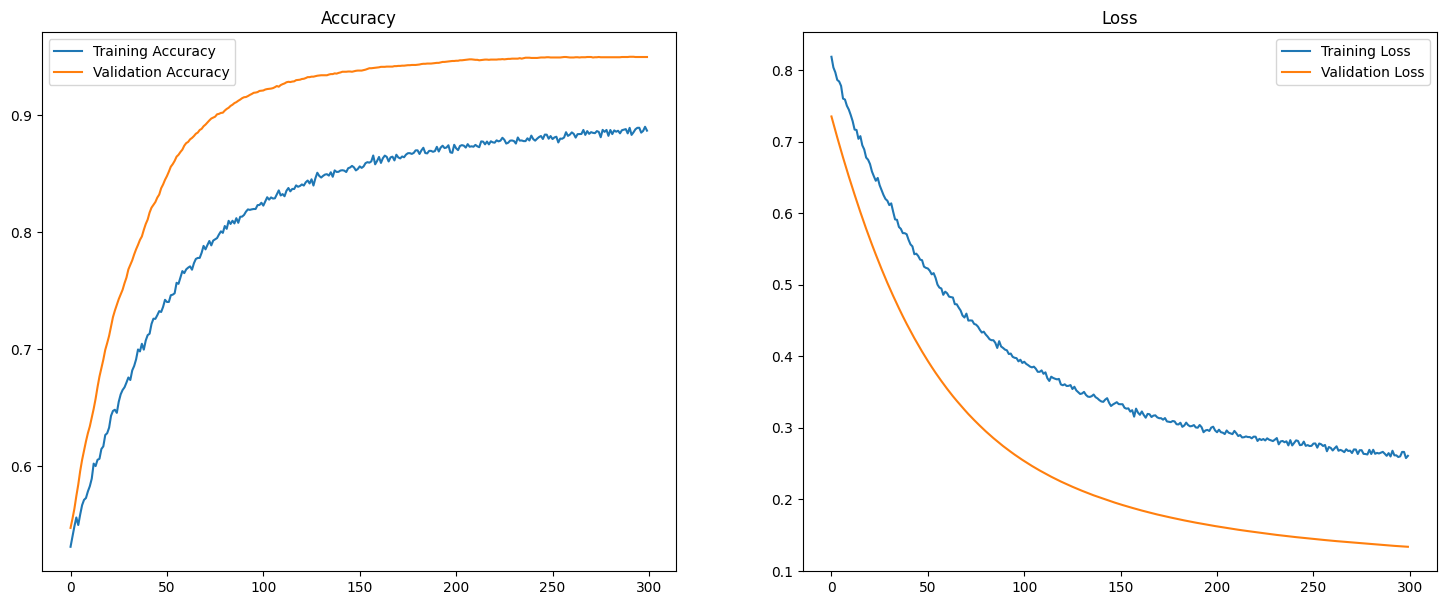

In [79]:
plot_learning_curves(history)

### Generate Predictions (TensorFlow to NumPy)

In [82]:
loss, accuracy = model.evaluate(validation_dataset)

print(f"Model Loss: {loss:.2f}")
print(f"Model Accuracy: {accuracy:.2f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9500 - loss: 0.1339
Model Loss: 0.13
Model Accuracy: 0.95


In [89]:
y_true = []
y_pred = []
y_prob = []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=1) # Try verbose=0
    y_prob.append(preds)
    y_pred.append(preds >= 0.5)
    y_true.append(labels.numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━

In [90]:
len(y_true), len(y_pred), len(y_prob)

(390, 390, 390)

In [91]:
y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)
y_prob = np.concatenate(y_prob)

### Core Classification Metrics (from scikit-learn)

In [92]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)



print(f"Accuracy: {accuracy_score(y_true, y_pred)}")
print(f"Precision (macro): {precision_score(y_true, y_pred)}")
print(f"Recall (macro): {recall_score(y_true, y_pred):.2f}")
print(f"F1-score (macro): {f1_score(y_true, y_pred):.2f}")

Accuracy: 0.957387047588476
Precision (macro): 0.9524339802736239
Recall (macro): 0.96
F1-score (macro): 0.96


In [93]:
# Full Classification Report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))


              precision    recall  f1-score   support

        cats     0.9624    0.9521    0.9572      6242
        dogs     0.9524    0.9627    0.9575      6219

    accuracy                         0.9574     12461
   macro avg     0.9574    0.9574    0.9574     12461
weighted avg     0.9574    0.9574    0.9574     12461



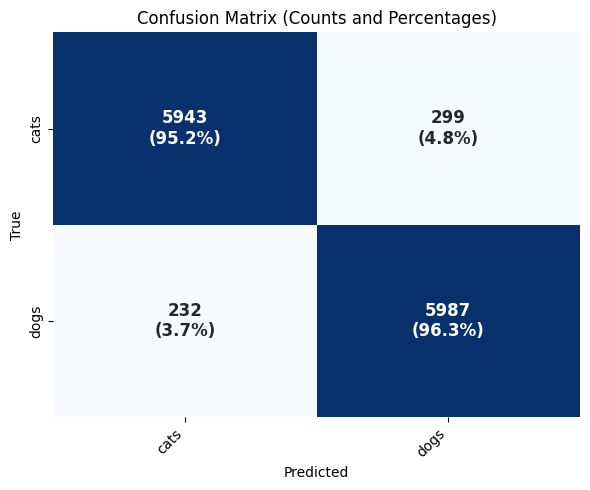

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))

# Create custom annotations showing both count and percentage
annot_text = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot_text[i, j] = f'{cm[i, j]}\n({cm_norm[i, j]:.1%})'

sns.heatmap(cm, 
            cmap="Blues", 
            cbar=False, 
            annot=annot_text, 
            fmt='',  # fmt='' for string annotations
            xticklabels=class_names,
            yticklabels=class_names,
            
            # kwargs for annotation text
            annot_kws={"fontsize": 12, "fontweight": "bold"},)  

plt.title("Confusion Matrix (Counts and Percentages)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")

# Adjust layout to prevent text cutoff
plt.tight_layout()  
plt.show()

In [104]:
# Saving the Model

model.save("dogs_cat_MobileNetV3.keras")

**This resulted in a poor model. We will use transfer learning to see how to improve the model using any of the model which is already doing well in general image processing tasks.**